# Анализ системы метрик приложения

### Данные

Данные собраны в трёх датасетах.

1. Датасет `ppro_visits.csv` — информация о посещениях приложения пользователями, которые зарегистрировались с 1 апреля 2024 года по 30 ноября 2024 года:
    - `user_id` — уникальный идентификатор пользователя;
    - `region` — страна пользователя;
    - `device` — категория устройства пользователя;
    - `channel` — идентификатор рекламного источника, из которого пришёл пользователь;
    - `session_start` — дата и время начала сессии;
    - `session_end` — дата и время окончания сессии.

2. Датасет `ppro_orders.csv` — информация о покупках:
    - `user_id` — уникальный идентификатор пользователя, который сделал покупку;
    - `event_dt` — дата и время покупки;
    - `revenue` — выручка.

3. Датасет `ppro_costs.csv` — информация о затратах на маркетинг:
    - `dt` — дата
    - `channel` — идентификатор рекламного источника;
    - `costs` — затраты на этот рекламный источник в этот день.
    
### План проекта
- Загрузить и предобработать данные.
- Подготовить данные для когортного анализа.
- Рассчитать и проанализировать метрики вовлечённости в продукт.
- Рассчитать и проанализировать финансовые метрики CAC, LTV и ROI за первые 28 дней с момента привлечения.
- Исследовать метрики в разрезе источника привлечения.
- Рассчитать период окупаемости маркетинговых вложений.
- Сформулировать выводы и рекомендации.


## Загрузка и предобработка данных



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

path_visits = 'https://code.s3.yandex.net/datasets/ppro_visits.csv'
path_orders = 'https://code.s3.yandex.net/datasets/ppro_orders.csv'
path_costs = 'https://code.s3.yandex.net/datasets/ppro_costs.csv'

# Создаём датафреймы для трёх таблиц
df_visits = pd.read_csv(path_visits)
df_orders = pd.read_csv(path_orders)
df_costs = pd.read_csv(path_costs)

# Выводим на экран размер исходных таблиц
print(df_visits.shape, df_orders.shape, df_costs.shape)

(161865, 6) (33893, 3) (976, 3)


In [ ]:
display(df_visits.head(5))
display(df_orders.head(5))
display(df_costs.head(5))

,user_id,region,device,channel,session_start,session_end
0,631105188566,India,desktop,MediaTornado,2024-04-01 03:48:00,2024-04-01 04:19:00
1,892885906464,India,tv,RocketSuperAds,2024-04-01 00:47:00,2024-04-01 01:14:00
2,517003690029,India,mobile,MediaTornado,2024-04-01 17:31:00,2024-04-01 17:53:00
3,185156659289,India,mobile,MediaTornado,2024-04-01 14:36:00,2024-04-01 14:51:00
4,409503040345,India,mobile,RocketSuperAds,2024-04-01 08:25:00,2024-04-01 08:45:00


,user_id,event_dt,revenue
0,771951256319,2024-04-01 05:56:26,2.99
1,829942381059,2024-04-01 14:55:02,2.99
2,727879856738,2024-04-01 22:15:09,14.99
3,481270888930,2024-04-01 06:05:14,2.99
4,844695029762,2024-04-01 01:19:52,2.99


,dt,channel,costs
0,2024-04-01,FaceBoom,124.938874
1,2024-04-02,FaceBoom,88.147779
2,2024-04-03,FaceBoom,120.779457
3,2024-04-04,FaceBoom,98.981253
4,2024-04-05,FaceBoom,109.044760


In [ ]:
#типы данных
df_visits.dtypes

user_id           int64
region           object
device           object
channel          object
session_start    object
session_end      object
dtype: object

In [ ]:
df_orders.dtypes

user_id       int64
event_dt     object
revenue     float64
dtype: object

In [ ]:
df_costs.dtypes

dt          object
channel     object
costs      float64
dtype: object

In [ ]:
#поиск дублей
def check_double(df, name):
    print(f"=== {name} ===")
    print(f"Дубликаты: {df.duplicated().sum()}")

check_double(df_visits, "Таблица 1")
check_double(df_orders, "Таблица 2")
check_double(df_costs, "Таблица 3")

=== Таблица 1 ===
Дубликаты: 0
=== Таблица 2 ===
Дубликаты: 0
=== Таблица 3 ===
Дубликаты: 0


In [ ]:
#пропуски
def check_null(df, name):
    print(f"=== {name} ===")
    print(f"Пропуски:\n{df.isnull().sum()}")

check_null(df_visits, "Таблица 1")
check_null(df_orders, "Таблица 2")
check_null(df_costs, "Таблица 3")

=== Таблица 1 ===
Пропуски:
user_id          0
region           0
device           0
channel          0
session_start    0
session_end      0
dtype: int64
=== Таблица 2 ===
Пропуски:
user_id     0
event_dt    0
revenue     0
dtype: int64
=== Таблица 3 ===
Пропуски:
dt         0
channel    0
costs      0
dtype: int64


Типы данных в таблицах: в таблице `df_visits` можно поменять тип данных у `session_start` и `session_end` на datetime, в таблице `df_orders` у столбца `event_dt`, в таблице `df_costs` у `dt`. Дублей и пропусков нет.

In [ ]:
# Преобразование дат
df_visits['session_start'] = pd.to_datetime(df_visits['session_start'])
df_visits['session_end'] = pd.to_datetime(df_visits['session_end'])
df_orders['event_dt'] = pd.to_datetime(df_orders['event_dt'])
df_costs['dt'] = pd.to_datetime(df_costs['dt'])

## Подготовка данных к когортному анализу

Подготовим данные к когортному анализу с учётом того, что будем изучать окупаемость привлечения пользователей за первые 28 дней.

In [ ]:
# сортируем
visits_sorted = df_visits.sort_values(['user_id', 'session_start'])

# находим дату первой сессии и канал привлечения по визитам
visited = visits_sorted.groupby('user_id').agg({
    'session_start': 'first',
    'channel': 'first'
}).reset_index()

#переименовываем столбцы
visited.columns = ['user_id', 'first_dt', 'first_channel']
visited['first_dt'] = pd.to_datetime(visited['first_dt'])

print(f"Всего пользователей: {len(visited)}")


Всего пользователей: 74856


In [ ]:
# CAC = стоимость привлечения 1 клиента -> затраты/клиенты
# Шаг 3: Расчет стоимости привлечения (CAC) для каждого пользователя

# Находим первую сессию для каждого пользователя
# сортируем
visits_sorted = df_visits.sort_values(['user_id', 'session_start'])

# находим дату первой сессии и канал привлечения по визитам
daily_users_total = visits_sorted.groupby('user_id').agg({
    'session_start': 'first',
    'channel': 'first'
}).reset_index()

daily_users_total.columns = ['user_id', 'first_session_dt', 'first_channel']
daily_users_total['first_session_date'] = daily_users_total['first_session_dt'].dt.date
daily_users_total['first_session_date'] = pd.to_datetime(daily_users_total['first_session_date'])


# Считаем количество пользователей по датам и каналам первой сессии
cohort_size = daily_users_total.groupby(['first_session_date', 'first_channel']).agg({
    'user_id': 'nunique'
}).reset_index()

cohort_size.columns = ['dt', 'channel', 'cohort_users_count']


# Суммируем затраты по каналам за каждый день
daily_costs_by_channel = df_costs.groupby(['dt', 'channel']).agg({
    'costs': 'sum'
}).reset_index()


# Объединяем затраты с размером когорты по дате и каналу
costs_with_cohort = pd.merge(daily_costs_by_channel, cohort_size, on=['dt', 'channel'], how='right')
costs_with_cohort['costs'] = costs_with_cohort['costs'].fillna(0)

# Расчет CAC на пользователя за каждый день и канал
costs_with_cohort['cac'] = costs_with_cohort['costs'] / costs_with_cohort['cohort_users_count']


# Добавляем информацию о CAC к первой сессии каждого пользователя
first_sessions_with_cac = pd.merge(
    daily_users_total,
    costs_with_cohort[['dt', 'channel', 'cac', 'costs', 'cohort_users_count']],
    left_on=['first_session_date', 'first_channel'],
    right_on=['dt', 'channel'],
    how='left'
).drop(['dt', 'channel'], axis=1)

# Заполняем пропуски
first_sessions_with_cac['cac'] = first_sessions_with_cac['cac'].fillna(0)
first_sessions_with_cac['costs'] = first_sessions_with_cac['costs'].fillna(0)
first_sessions_with_cac['cohort_users_count'] = first_sessions_with_cac['cohort_users_count'].fillna(0)


# Объединяем с основными профилями пользователей
profiles = pd.merge(
    daily_users_total,
    first_sessions_with_cac[['user_id', 'first_session_dt', 'cac', 'costs', 'cohort_users_count']],
    on='user_id',
    how='left'
)


profiles = profiles[['user_id', 'first_session_dt_x', 'first_channel',  'cac']]
profiles.columns = ['user_id', 'first_dt', 'first_channel', 'cac']
profiles['first_dt'] = pd.to_datetime(profiles['first_dt'])


display(profiles)

,user_id,first_dt,first_channel,cac
0,26034876,2024-05-29 10:24:00,FaceBoom,0.953250
1,69890364,2024-06-28 05:48:00,RocketSuperAds,0.604917
2,75610104,2024-06-09 06:48:00,FaceBoom,1.196159
3,76692397,2024-10-21 01:51:00,FaceBoom,1.147967
4,80224421,2024-06-21 11:47:00,FaceBoom,1.208981
...,...,...,...,...
74851,999956504962,2024-07-04 08:38:00,MediaTornado,0.267129
74852,999959994517,2024-06-03 13:01:00,RocketSuperAds,0.829762
74853,999962248443,2024-10-27 14:41:00,RocketSuperAds,0.411066
74854,999970372492,2024-08-07 19:54:00,TipTop,2.103363


In [ ]:
# Добавляем информацию о первом источнике привлечения к визитам
visits_reached = df_visits.merge(
    profiles[['user_id', 'first_dt', 'first_channel', 'cac']],
    on='user_id',
    how='left'
)

# Добавляем информацию о первом источнике привлечения к заказам
orders_reached = df_orders.merge(
    profiles[['user_id', 'first_dt', 'first_channel', 'cac']],
    on='user_id',
    how='left'
)

рассчитаем дневной лайфтайм для каждого события или покупки и добавьте в таблицу в виде целого числа

In [ ]:
visits_reached['diff_days'] = (visits_reached['session_start'] - visits_reached['first_dt']).dt.days
orders_reached['diff_days'] = (orders_reached['event_dt'] - orders_reached['first_dt']).dt.days

## Анализ месячной динамики основных метрик продукта

Начнем анализ данных с изучения динамики активности пользователей и их вовлечённости в продукт.

В разрезе каждого месяца привлечения новых пользователей рассчитаем:
- Среднюю стоимость привлечения пользователя (CAC).
- Значение LTV и ROI с учётом покупок, совершённых за 28 дней с момента привлечения.

In [ ]:
#Для расчёта DAU посчитаем количество уникальных пользователей в разрезе дня
df_visits['session_start'] = pd.to_datetime(df_visits['session_start'])
df_visits['session_end'] = pd.to_datetime(df_visits['session_end'])

#столбец с датой
df_visits['date'] = df_visits['session_start'].dt.date


dau = df_visits.groupby('date')['user_id'].nunique().reset_index()
dau.columns = ['date', 'dau']
dau['date'] = pd.to_datetime(dau['date'])

dau.head(5)

,date,dau
0,2024-04-01,356
1,2024-04-02,410
2,2024-04-03,481
3,2024-04-04,472
4,2024-04-05,533


In [ ]:
#Расчет MAU - кол-во уникальных пользователей в разрезе месяца

df_visits['year_month'] = df_visits['session_start'].dt.to_period('M')
mau = df_visits.groupby('year_month')['user_id'].nunique().reset_index()
mau.columns = ['year_month', 'mau']
mau['year_month'] = mau['year_month'].dt.to_timestamp()
mau.head(5)

,year_month,mau
0,2024-04-01,9069
1,2024-05-01,10849
2,2024-06-01,10240
3,2024-07-01,10864
4,2024-08-01,11977


Stickiness Ratio помогают понять, насколько хорошо продукт удерживает аудиторию, = DAU/MAU *100

In [ ]:
dau_with_month = dau.copy()
dau_with_month['year_month'] = dau_with_month['date'].dt.to_period('M').dt.to_timestamp()

stickiness = dau_with_month.merge(mau, on='year_month', how='left')

stickiness['stickiness'] = (stickiness['dau'] / stickiness['mau']) * 100

stickiness.head(5)

,date,dau,year_month,mau,stickiness
0,2024-04-01,356,2024-04-01,9069,3.925460
1,2024-04-02,410,2024-04-01,9069,4.520895
2,2024-04-03,481,2024-04-01,9069,5.303782
3,2024-04-04,472,2024-04-01,9069,5.204543
4,2024-04-05,533,2024-04-01,9069,5.877164


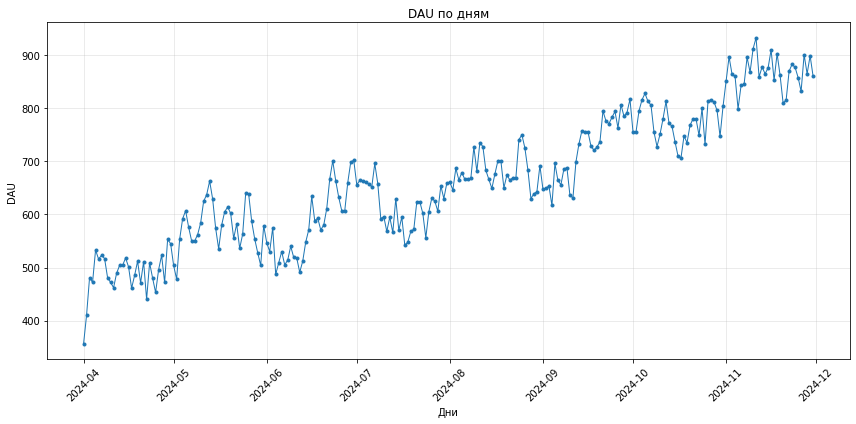

In [ ]:
#визуализируем DAU

plt.figure(figsize=(12, 6))

plt.plot(dau['date'], dau['dau'], marker='o', linewidth=1, markersize=3)


plt.title('DAU по дням')
plt.xlabel('Дни')
plt.ylabel('DAU')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Заметен рост в 2 раза уникальных пользователей за весь период пользования приложением.

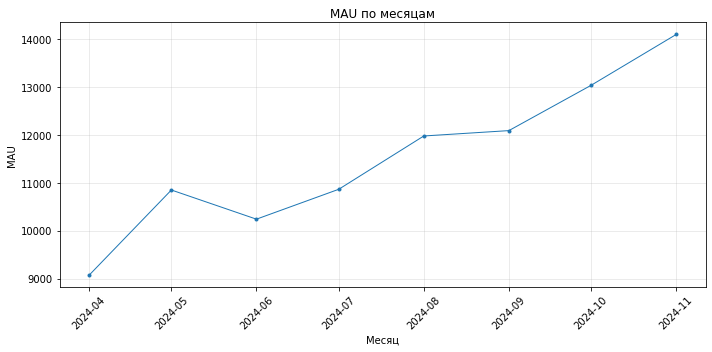

In [ ]:
#визуализируем MAU

plt.figure(figsize=(10, 5))

plt.plot(mau['year_month'], mau['mau'], marker='o', linewidth=1, markersize=3)


plt.title('MAU по месяцам')
plt.xlabel('Месяц')
plt.ylabel('MAU')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Пользователи ежемесячно пользуются продуктом, рост есть и он стабилен.

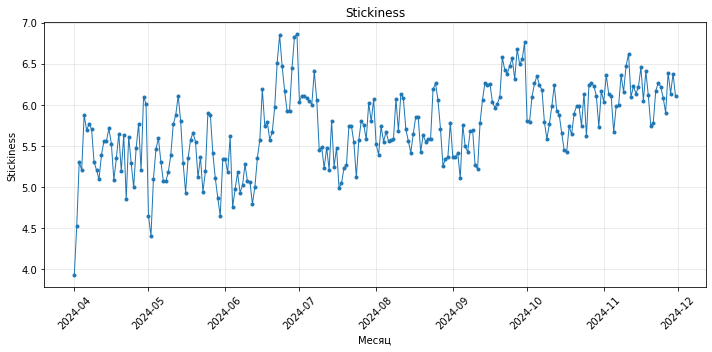

In [ ]:
#визуализируем Stickiness (DAU/MAU)

plt.figure(figsize=(10, 5))

plt.plot(stickiness['date'], stickiness['stickiness'], marker='o', linewidth=1, markersize=3)


plt.title('Stickiness')
plt.xlabel('Месяц')
plt.ylabel('Stickiness')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Возвращаемость в приложение почти линейная несмотря на рост уникальных пользователей. Все же не все остаются пользоваться приложением. С июня заметен скачок, дальше небольшой прирост показателя липкости.


- Среднюю стоимость привлечения пользователя (CAC) по месяцам

In [ ]:
#дата привлечения и первый канал для каждого пользователя без разбивки по каналам
profiles['cohort_month'] = profiles['first_dt'].dt.to_period('M')

profiles_cut = profiles[['user_id', 'first_channel', 'cohort_month']]


#cчитаем количество новых пользователей по месяцам и каналам
new_users_monthly = profiles.groupby('cohort_month')['user_id'].nunique().reset_index()

new_users_monthly.columns = ['month', 'total_users']

profiles.head(5)

,user_id,first_dt,first_channel,cac,cohort_month
0,26034876,2024-05-29 10:24:00,FaceBoom,0.953250,2024-05
1,69890364,2024-06-28 05:48:00,RocketSuperAds,0.604917,2024-06
2,75610104,2024-06-09 06:48:00,FaceBoom,1.196159,2024-06
3,76692397,2024-10-21 01:51:00,FaceBoom,1.147967,2024-10
4,80224421,2024-06-21 11:47:00,FaceBoom,1.208981,2024-06


In [ ]:
costs_monthly = df_costs.copy()
costs_monthly['month'] = costs_monthly['dt'].dt.to_period('M')
monthly_costs = costs_monthly.groupby('month')['costs'].sum().reset_index()

monthly_costs.head(5)

,month,costs
0,2024-04,6663.052333
1,2024-05,7327.775412
2,2024-06,8492.116887
3,2024-07,9217.078561
4,2024-08,10999.013650


In [ ]:
# Объединяем общие затраты с общим количеством пользователей
df_CAC = monthly_costs.merge(new_users_monthly, on='month', how='inner')

# Рассчитываем стоимость привлечения клиента
df_CAC['CAC'] = df_CAC['costs'] / df_CAC['total_users']
df_CAC

,month,costs,total_users,CAC
0,2024-04,6663.052333,9069,0.734706
1,2024-05,7327.775412,9789,0.748572
2,2024-06,8492.116887,8719,0.973978
3,2024-07,9217.078561,8742,1.054344
4,2024-08,10999.013650,9518,1.155601
5,2024-09,10838.014747,9198,1.178301
6,2024-10,12595.403113,9520,1.323047
7,2024-11,13598.849128,10301,1.320148


- Значение LTV и ROI с учётом покупок, совершённых за 28 дней с момента привлечения

In [ ]:
#LTV
#соединим таблицу с заказами и пользователями со столбцом с датой привлечения из канала
orders_with_cohort = df_orders.merge(
    profiles[['user_id', 'first_dt', 'cohort_month', 'first_channel']],
    on='user_id',
    how='left'
)

#лайфтайм покупки
orders_with_cohort['n_period'] = (orders_with_cohort['event_dt'] - orders_with_cohort['first_dt']).dt.days

#оставляем покупки, совершённых за 28 дней с момента привлечения
orders_28d = orders_with_cohort[orders_with_cohort['n_period'] < 28]

# Суммируем выручку за 28 дней по пользователям и месяцам привлечения
user_revenue_28d = orders_28d.groupby(['user_id', 'cohort_month'])['revenue'].sum().reset_index()


# Добавляем LTV к профилям пользователей
profiles_with_ltv = pd.merge(
    profiles,
    user_revenue_28d[['user_id', 'revenue']],
    on='user_id',
    how='left',
    suffixes=('', '_28d')
)

profiles_with_ltv['ltv_28d'] = profiles_with_ltv['revenue']


monthly_ltv = profiles_with_ltv.groupby('cohort_month').agg({
    'revenue': 'sum',
    'user_id': 'count'
}).reset_index()

monthly_ltv.columns = ['month', 'total_revenue_28d', 'total_users_ltv']

#Объединяем с CAC данными
df_CAC_total = df_CAC.merge(monthly_ltv[['month', 'total_revenue_28d']],
                                    on='month', how='left')


# Пересчитываем LTV как среднюю выручку на пользователя за 28 дней
df_CAC_total['avg_ltv_28d'] = df_CAC_total['total_revenue_28d'] / df_CAC_total['total_users']

df_CAC_total['roi_28d'] = (df_CAC_total['avg_ltv_28d'] - df_CAC_total['CAC']) / df_CAC_total['CAC'] * 100

df_CAC_total

,month,costs,total_users,CAC,total_revenue_28d,avg_ltv_28d,roi_28d
0,2024-04,6663.052333,9069,0.734706,7476.47,0.824399,12.207884
1,2024-05,7327.775412,9789,0.748572,8182.65,0.835903,11.666223
2,2024-06,8492.116887,8719,0.973978,7506.16,0.860897,-11.610260
3,2024-07,9217.078561,8742,1.054344,10060.27,1.150797,9.148142
4,2024-08,10999.013650,9518,1.155601,10445.32,1.097428,-5.034030
5,2024-09,10838.014747,9198,1.178301,10145.70,1.103033,-6.387837
6,2024-10,12595.403113,9520,1.323047,11524.47,1.210554,-8.502571
7,2024-11,13598.849128,10301,1.320148,8896.97,0.863700,-34.575567


Визуализируем метрики

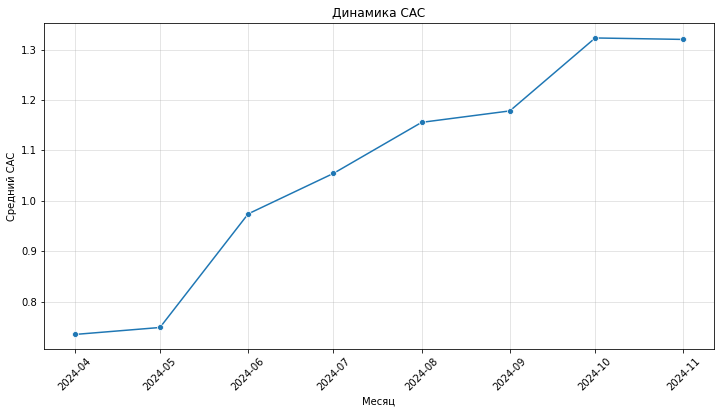

In [ ]:
#CAC

# Конвертируем month в timestamp для корректной работы с осью времени
df_CAC_total['month'] = df_CAC_total['month'].dt.to_timestamp()

# Инициализируем холст для графика
plt.figure(figsize=(12, 6))

# Строим линейный график с разделением по типам трафика
sns.lineplot(
    data=df_CAC_total,
    x='month',
    y='CAC',
    ci=False,
    marker='o',
)

# Настраиваем отображение подписей
plt.xticks(rotation=45)
plt.grid(alpha=.4)

# Добавляем подписи осей
plt.xlabel('Месяц')
plt.ylabel('Средний CAC')

# Добавляем заголовок
plt.title('Динамика CAC')

plt.show()

CAC в динамике с июня показывает существенный рост.

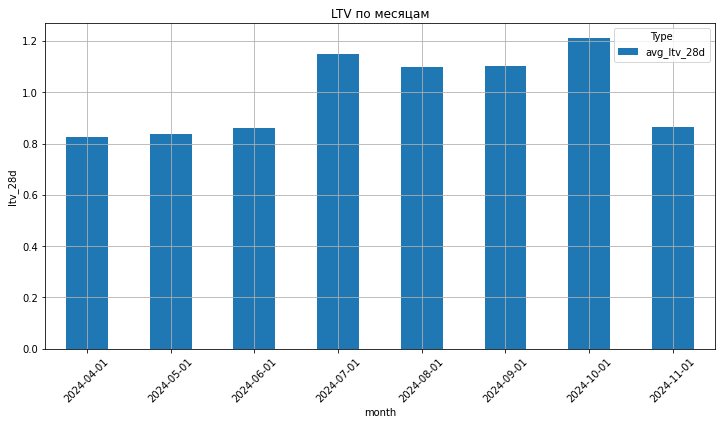

In [ ]:
#LTV

# Преобразуем месяц в строковый формат без времени
df_CAC_total['month_str'] = df_CAC_total['month'].astype(str)

# Построим barplot
df_CAC_total.plot(x='month_str', y='avg_ltv_28d', kind='bar', figsize=(12, 6))

plt.title('LTV по месяцам')
plt.xlabel('month')
plt.ylabel('ltv_28d')
plt.xticks(rotation=45)
plt.legend(title='Type')

plt.grid(True)
plt.show()

LTV с июля начало расти на несколько процентов, в ноябре вернулся к показателю июня.

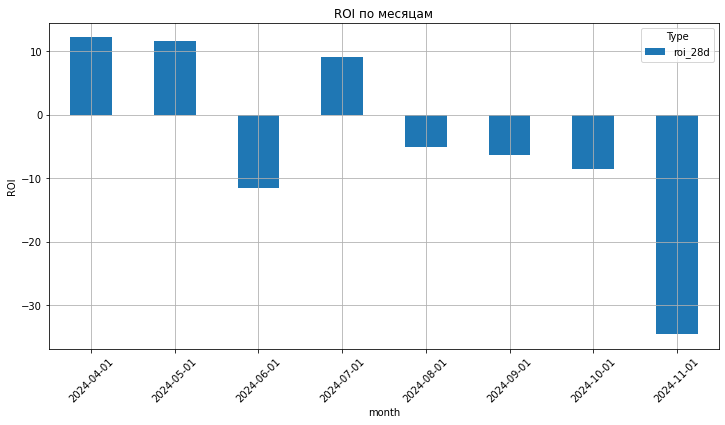

In [ ]:
#ROI
# Построим barplot
df_CAC_total.plot(x='month_str', y='roi_28d', kind='bar', figsize=(12, 6))

plt.title('ROI по месяцам')
plt.xlabel('month')
plt.ylabel('ROI')
plt.xticks(rotation=45)
plt.legend(title='Type')

plt.grid(True)
plt.show()

Наблюдается рост посетителей приложения стабильно до конца года, но по Stickiness Ratio пользователи только на один пункт лучше стали возвращаться в продукт. Среднее количество новых пользователей выросло.

Пожизненная ценность клиента LTV показывает рост, особенно заметен рост с июля и до конца октября. В ноябре показатель упал к уровню июня. Общая выручка за 28 дней выросла.

Видим резкий рост CAC с июня: увеличился с 0.74 до 1.18 (+59%), затраты на привлечение растут быстрее ценности. Отрицательный ROI: С июня ROI стал отрицательным, достигнув -34.6% в ноябре. Несмотря на рост LTV, рост CAC оказался непропорциональным.

Новый контент положительно повлиял на ценность пользователей, но маркетинговая стратегия требует корректировки для достижения окупаемости.



## Анализ метрик в разрезе источника привлечения

Теперь необходимо разобраться, какие источники привлечения перспективны, а какие за 28 дней не окупились.

Определим самые популярные источники привлечения.

Изучим динамику изменения метрик на 28-й день в разрезе источника. Проведем анализ с выделением недельных когорт по дате привлечения. Рассчитаем и визуализируем:
- Скользящее удержание на 14-й день с момента привлечения (за период с 14-го по 28-й день).
- Конверсию в покупку.


In [ ]:
#Посчитайте общее число привлечённых пользователей для каждого источника
channel_users_all = profiles.groupby('first_channel')['user_id'].nunique().sort_values(ascending=False)
channel_users_all

first_channel
FaceBoom          28401
TipTop            18118
RocketSuperAds    14257
MediaTornado      14080
Name: user_id, dtype: int64

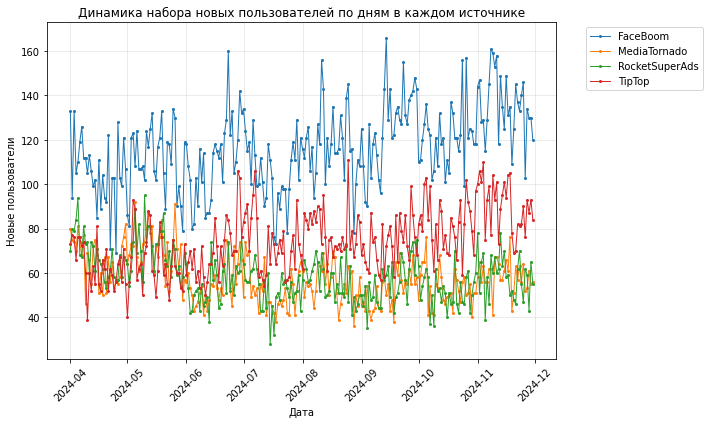

In [ ]:
#Визуализируйте динамику набора новых пользователей по дням в каждом источнике
daily_new_users = profiles.groupby([
    profiles['first_dt'].dt.date,
    'first_channel'])['user_id'].nunique().reset_index()

plt.figure(figsize=(10, 6))

for channel in daily_new_users['first_channel'].unique():
    channel_data = daily_new_users[daily_new_users['first_channel'] == channel]
    plt.plot(channel_data['first_dt'], channel_data['user_id'],
             marker='o', markersize=2, linewidth=1, label=channel)

plt.title('Динамика набора новых пользователей по дням в каждом источнике')
plt.xlabel('Дата')
plt.ylabel('Новые пользователи')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

В большом количестве новые пользователи приходят из FaceBoom, с середины августа рост увеличился. Из канала TicTop пользователи приходят почти равномерно, с ростом с августа. Из MediaTornado и RocketSuperAds трафик почти одинаков, к концу года незаметный спад.

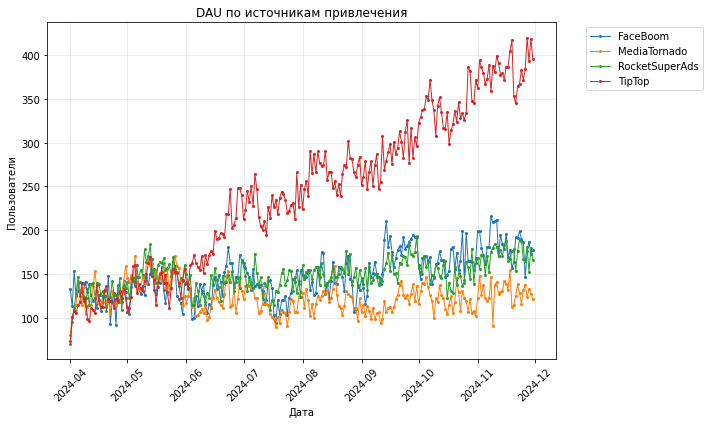

In [ ]:
#Рассчитайте и визуализируйте динамику DAU, MAU и Stickiness по источникам привлечения

#DAU
# Добавляем информацию о первом канале привлечения к визитам
visits_with_channel = df_visits.merge(
    profiles[['user_id', 'first_channel']],
    on='user_id',
    how='left'
)

# DAU по каналам
visits_with_channel['date'] = visits_with_channel['session_start'].dt.date
dau_by_channel = visits_with_channel.groupby(['date', 'first_channel'])['user_id'].nunique().reset_index()
dau_by_channel['date'] = pd.to_datetime(dau_by_channel['date'])

plt.figure(figsize=(10, 6))


for channel in dau_by_channel['first_channel'].unique():
    channel_data = dau_by_channel[dau_by_channel['first_channel'] == channel]
    plt.plot(channel_data['date'], channel_data['user_id'],
             marker='o', markersize=2, linewidth=1, label=channel)

plt.title('DAU по источникам привлечения')
plt.xlabel('Дата')
plt.ylabel('Пользователи')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Высокий рост пользователей приходит из канала TipTop с июня, по остальным каналам пользователи приходят равномерно

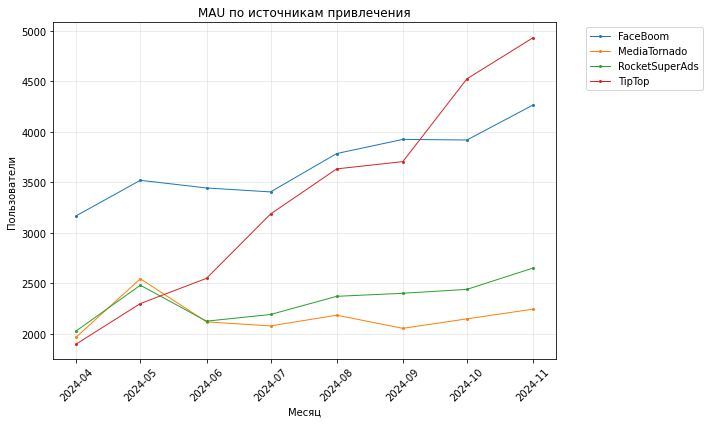

In [ ]:
#MAU

visits_with_channel['month'] = visits_with_channel['session_start'].dt.to_period('M')
mau_by_channel = visits_with_channel.groupby(['month', 'first_channel'])['user_id'].nunique().reset_index()

mau_by_channel['month'] = mau_by_channel['month'].dt.to_timestamp()


plt.figure(figsize=(10, 6))


for channel in mau_by_channel['first_channel'].unique():
    channel_data = mau_by_channel[mau_by_channel['first_channel'] == channel]
    plt.plot(channel_data['month'], channel_data['user_id'],
             marker='o', markersize=2, linewidth=1, label=channel)

plt.title('MAU по источникам привлечения')
plt.xlabel('Месяц')
plt.ylabel('Пользователи')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Наблюдается рост месячной аудитории у канала TipTop и Faceboom.

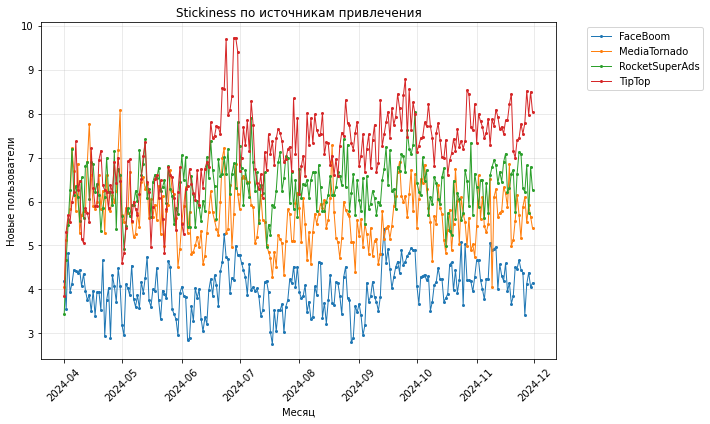

In [ ]:
#Stickiness
dau_by_channel['month'] = dau_by_channel['date'].dt.to_period('M').dt.to_timestamp()

stickiness_by_channel = dau_by_channel.merge(mau_by_channel, on=['month', 'first_channel'], how='left')
stickiness_by_channel.columns = ['date', 'first_channel', 'dau', 'month', 'mau']

stickiness_by_channel['stickiness'] = (stickiness_by_channel['dau'] / stickiness_by_channel['mau']) * 100



plt.figure(figsize=(10, 6))


for channel in stickiness_by_channel['first_channel'].unique():
    channel_data = stickiness_by_channel[stickiness_by_channel['first_channel'] == channel]
    plt.plot(channel_data['date'], channel_data['stickiness'],
             marker='o', markersize=2, linewidth=1, label=channel)

plt.title('Stickiness по источникам привлечения')
plt.xlabel('Месяц')
plt.ylabel('Новые пользователи')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Несмотря на значительный рост по каналу TipTop пользователи не возвращаются в продукт так часто. Канал FaceBoom тоже показывает низкий % возвращаемости в приложение

Задача 2

In [ ]:
#Скользящее удержание на 14-й день с момента привлечения (за период с 14-го по 28-й день)

visits_with_cohort = df_visits.merge(
    profiles[['user_id', 'first_dt', 'cohort_month', 'first_channel']],
    on='user_id',
    how='inner'
)

visits_with_cohort['n_days'] = (
    visits_with_cohort['session_start'] - visits_with_cohort['first_dt']
).dt.days

#Оставим только события, совершенные в первые 28 дней
visits_28d = visits_with_cohort[visits_with_cohort['n_days'] < 28].copy()

#Выделим неделю первого посещения
visits_28d['first_dt'] = pd.to_datetime(visits_28d['first_dt'])
visits_28d['first_week'] = visits_28d['first_dt'].dt.to_period('W').dt.to_timestamp()


# Рассчитаем размер когорты на первый день
first_day = visits_28d[visits_28d['n_days'] == 0]
first_series_users = (first_day.groupby(['first_channel', 'first_week'])['user_id'].nunique().reset_index())


# Считаем размер когорт на 14 и последующие дни
fourteenth_day_plus = visits_28d[visits_28d['n_days'] >= 14]
active_users_14plus = fourteenth_day_plus.groupby(['first_channel', 'first_week'])['user_id'].nunique().reset_index()

# Соединяем данные, фильтруем по октябрь
retention_df = first_series_users.merge(active_users_14plus, on=['first_channel', 'first_week'], how='left')
retention_df = retention_df.rename(columns={
    'user_id_x': 'cohort_size',
    'user_id_y': 'active_users_14plus'
})
# Рассчитываем rolling retention
retention_df['rolling_retention_14day'] = (retention_df['active_users_14plus'] / retention_df['cohort_size']) * 100

# Сортируем для расчета скользящего среднего
retention_df = retention_df.sort_values(['first_channel', 'first_week'])

# Применяем скользящее среднее
retention_data_sorted = retention_df.sort_values(['first_channel', 'first_week'])


# Рассчитываем скользящее среднее по 2 неделям
retention_data_sorted['rolling_retention_ma'] = retention_data_sorted.groupby('first_channel')['rolling_retention_14day'].transform(
    lambda x: x.rolling(window=2, min_periods=1).mean()
)


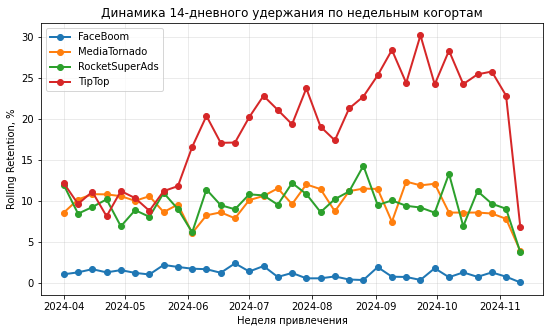

In [ ]:
#Визуализируем
plt.figure(figsize=(9, 5))

# Rolling Retention по каналам
for channel in retention_data_sorted['first_channel'].unique():
    channel_data = retention_data_sorted[retention_data_sorted['first_channel'] == channel]
    plt.plot(channel_data['first_week'], channel_data['rolling_retention_14day'],
             marker='o', linewidth=2, label=channel)

plt.title('Динамика 14-дневного удержания по недельным когортам')
plt.xlabel('Неделя привлечения')
plt.ylabel('Rolling Retention, %')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)


TipTop показывает лучший процент удержания на 14 день. Средняя эффективность у RocketSuperAds и MediaTornado (8-9%). У FaceBoom самая низкая эффективность в удержание клиента.

In [ ]:
# Конверсия в покупку за 28 дней по недельным когортам

# Объединяем заказы с профилями
orders_with_cohort = df_orders.merge(
    profiles[['user_id', 'first_dt', 'first_channel']],
    on='user_id',
    how='inner'
)

# Лайфтайм покупок и фильтр 28 дней
orders_with_cohort['n_days'] = (orders_with_cohort['event_dt'] - orders_with_cohort['first_dt']).dt.days
orders_28d = orders_with_cohort[orders_with_cohort['n_days'] < 28].copy()


orders_28d['first_week'] = orders_28d['first_dt'].dt.to_period('W').dt.to_timestamp()

# Конверсия по неделям и каналам
conversion_weekly = orders_28d.groupby(['first_week', 'first_channel'])['user_id'].nunique().reset_index()

# Добавляем общее количество пользователей в когортах
cohort_sizes = profiles.groupby([
    profiles['first_dt'].dt.to_period('W').dt.to_timestamp(),
    'first_channel'
])['user_id'].nunique().reset_index()
cohort_sizes.columns = ['first_week', 'first_channel', 'total_users']

# Объединяем и считаем конверсию
conversion_df = conversion_weekly.merge(cohort_sizes, on=['first_week', 'first_channel'], how='left')
conversion_df['conversion_rate'] = (conversion_df['user_id'] / conversion_df['total_users'] * 100).round(2)


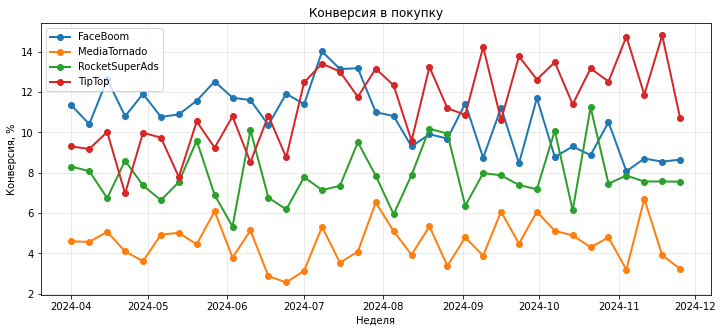

In [ ]:
#Визуализируем
plt.figure(figsize=(12, 5))

# Конверсия в покупку по каналам
for channel in conversion_df['first_channel'].unique():
    channel_data = conversion_df[conversion_df['first_channel'] == channel]
    plt.plot(channel_data['first_week'], channel_data['conversion_rate'],
             marker='o', linewidth=2, label=channel)

plt.title('Конверсия в покупку')
plt.xlabel('Неделя')
plt.ylabel('Конверсия, %')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)


Канал TipTop и FaceBoom показывают высокую конверсию, FaceBoom с июля показывает спад. Канал RocketSuperAds показывает стабильную конверсию, MediaTornado с самой низкой конверсией.

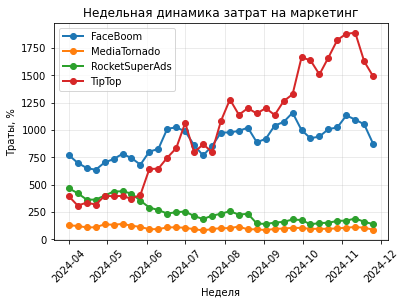

In [ ]:
#Недельную динамику затрат на маркетинг по каждому источнику привлечения.

costs_weekly = df_costs.copy()
costs_weekly['week'] = costs_weekly['dt'].dt.to_period('W').dt.to_timestamp()
weekly_costs = costs_weekly.groupby(['week', 'channel'])['costs'].sum().reset_index()


for channel in weekly_costs['channel'].unique():
    channel_data = weekly_costs[ weekly_costs['channel'] == channel]
    plt.plot(channel_data['week'], channel_data['costs'],
             marker='o', linewidth=2, label=channel)

plt.title('Недельная динамика затрат на маркетинг')
plt.xlabel('Неделя')
plt.ylabel('Траты, %')
plt.legend(loc='upper left')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)


В канал TipTop увеличили бюджет с июня в несколько раз ,видимо, посчитав, что это эффективный источник лидов. На втором месте канал FaceBoom по затратам. Снизили расходы у канала RocketSuperAds.

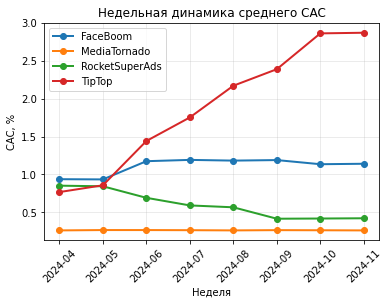

In [ ]:
#Динамику среднего CAC

# Суммируем затраты по месяцам и каналам

monthly_costs_by_channel = df_costs.copy()
monthly_costs_by_channel['month'] = monthly_costs_by_channel['dt'].dt.to_period('M')
monthly_costs_by_channel = monthly_costs_by_channel.groupby(['month', 'channel'])['costs'].sum().reset_index()


monthly_costs_by_channel.columns = ['month', 'channel', 'costs']

# Считаем количество новых пользователей по месяцам и каналам
new_users_monthly_by_channel = profiles.groupby(['cohort_month', 'first_channel'])['user_id'].nunique().reset_index()
new_users_monthly_by_channel.columns = ['month', 'channel', 'total_users']

# Объединяем
df_CAC_by_channel = monthly_costs_by_channel.merge(new_users_monthly_by_channel, on=['month', 'channel'], how='inner')

# Рассчитываем CAC
df_CAC_by_channel['CAC'] = df_CAC_by_channel['costs'] / df_CAC_by_channel['total_users']


for channel in df_CAC_by_channel['channel'].unique():
    channel_data = df_CAC_by_channel[df_CAC_by_channel['channel'] == channel]
    plt.plot(channel_data['month'].astype(str), channel_data['CAC'],
             marker='o', linewidth=2, label=channel)



plt.title('Недельная динамика среднего CAC')
plt.xlabel('Неделя')
plt.ylabel('CAC, %')
plt.legend(loc='upper left')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

Теперь видно, что рост CAC начался с июня за счет канала TipTop, в то время как CAC у каналов FaceBoom, MediaTornado не изменился, а у RocketSuperAds снизился с декабря.

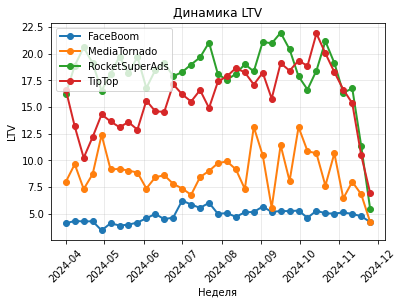

In [ ]:
#Динамика значений LTV только для событий, совершенные в первые 28 дней

ltv_data = orders_28d.groupby([
    orders_28d['first_dt'].dt.to_period('W').dt.to_timestamp(),
    'first_channel'
]).agg({
    'revenue': 'sum',
    'user_id': 'nunique'
}).reset_index()


ltv_data.columns = ['week', 'channel', 'total_revenue', 'paying_users']
ltv_data['ltv_28d'] = (ltv_data['total_revenue'] / ltv_data['paying_users']).round(2)

for channel in ltv_data['channel'].unique():
    channel_data = ltv_data[ltv_data['channel'] == channel]
    plt.plot(channel_data['week'], channel_data['ltv_28d'],
             marker='o', linewidth=2, label=channel)

plt.title('Динамика LTV')
plt.xlabel('Неделя')
plt.ylabel('LTV')
plt.legend(loc='upper left')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

In [ ]:
orders_28d

,user_id,event_dt,revenue,first_dt,first_channel,n_days,first_week
0,771951256319,2024-04-01 05:56:26,2.99,2024-04-01 05:56:00,FaceBoom,0,2024-04-01
1,829942381059,2024-04-01 14:55:02,2.99,2024-04-01 14:54:00,FaceBoom,0,2024-04-01
2,727879856738,2024-04-01 22:15:09,14.99,2024-04-01 22:14:00,FaceBoom,0,2024-04-01
3,481270888930,2024-04-01 06:05:14,2.99,2024-04-01 06:05:00,TipTop,0,2024-04-01
4,481270888930,2024-04-02 23:40:32,2.99,2024-04-01 06:05:00,TipTop,1,2024-04-01
...,...,...,...,...,...,...,...
33888,397577560536,2024-11-30 16:47:45,2.99,2024-11-30 16:47:00,RocketSuperAds,0,2024-11-25
33889,610390409217,2024-11-30 04:35:45,7.99,2024-11-30 04:35:00,TipTop,0,2024-11-25
33890,74116424793,2024-11-30 04:16:46,2.99,2024-11-30 04:16:00,FaceBoom,0,2024-11-25
33891,691138256176,2024-11-30 02:07:03,2.99,2024-11-30 02:06:00,FaceBoom,0,2024-11-25


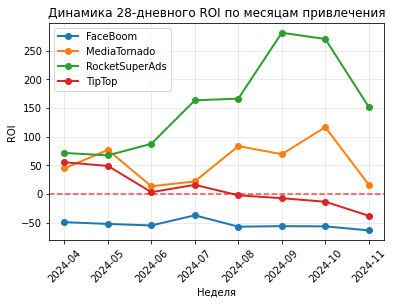

In [ ]:
#Динамика ROI только для событий, совершенные в первые 28 дней

# Суммируем выручку за 28 дней по пользователям, месяцам и каналам привлечения
user_revenue_28d_by_channel = orders_28d.groupby(['user_id', 'n_days', 'first_channel'])['revenue'].sum().reset_index()

# Добавляем LTV к профилям пользователей с учетом канала
profiles_with_ltv_by_channel = pd.merge(
    profiles,
    user_revenue_28d_by_channel[['user_id', 'revenue', 'first_channel']],
    on=['user_id', 'first_channel'],
    how='left',
    suffixes=('', '_28d')
)


# Агрегируем LTV по месяцам и каналам
monthly_ltv_by_channel = profiles_with_ltv_by_channel.groupby(['cohort_month', 'first_channel']).agg({
    'revenue': 'sum',
    'user_id': 'count'
}).reset_index()

monthly_ltv_by_channel.columns = ['month', 'channel', 'total_revenue_28d', 'total_users_ltv']


# Объединяем с CAC данными по каналам
df_CAC_total_by_channel = df_CAC_by_channel.merge(
    monthly_ltv_by_channel[['month', 'channel', 'total_revenue_28d']],
    on=['month', 'channel'],
    how='left'
)

# Пересчитываем LTV как среднюю выручку на пользователя за 28 дней
df_CAC_total_by_channel['avg_ltv_28d'] = df_CAC_total_by_channel['total_revenue_28d'] / df_CAC_total_by_channel['total_users']

# Рассчитываем ROI по каналам
df_CAC_total_by_channel['roi_28d'] = (df_CAC_total_by_channel['avg_ltv_28d'] - df_CAC_total_by_channel['CAC']) / df_CAC_total_by_channel['CAC'] * 100


for channel in df_CAC_total_by_channel['channel'].unique():
    channel_data = df_CAC_total_by_channel[df_CAC_total_by_channel['channel'] == channel]
    plt.plot(channel_data['month'].astype(str), channel_data['roi_28d'],
             marker='o', linewidth=2, label=channel)

plt.title('Динамика 28-дневного ROI по месяцам привлечения')
plt.xlabel('Неделя')
plt.ylabel('ROI')
plt.legend(loc='upper left')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7, label='Точка окупаемости')

## Анализ периода окупаемости маркетинговых вложений

Для источников, которые к 28-му дню не выходят на уровень окупаемости, рассчитаем и визуализируем в виде тепловой карты значения ROI за больший период, например за 8–10 недель.

Разделим данные на недельные когорты по дате привлечения, в качестве интервала наблюдений используем недели.

Исходя из динамики ROI по источникам проведем анализ дла каналов - TipTop, FaceBoom.

In [ ]:
# Определяем каналы с отрицательным ROI на 28 день
latest_week = df_CAC_total_by_channel['month'].max()
latest_roi = df_CAC_total_by_channel[df_CAC_total_by_channel['month'] == latest_week]

unprofitable_channels = latest_roi[latest_roi['roi_28d'] < 0]['channel'].tolist()
print(f"Каналы, не окупающиеся к 28 дню: {unprofitable_channels}")

Каналы, не окупающиеся к 28 дню: ['FaceBoom', 'TipTop']


In [ ]:
# Группировка всех пользователей по неделе их первого визита
profiles.head(4)

,user_id,first_dt,first_channel,cac,cohort_month
0,26034876,2024-05-29 10:24:00,FaceBoom,0.953250,2024-05
1,69890364,2024-06-28 05:48:00,RocketSuperAds,0.604917,2024-06
2,75610104,2024-06-09 06:48:00,FaceBoom,1.196159,2024-06
3,76692397,2024-10-21 01:51:00,FaceBoom,1.147967,2024-10


In [ ]:
orders_with_cohort['cohort_week'] = orders_with_cohort['first_dt'].dt.to_period('W').dt.to_timestamp()

In [ ]:
# Вычисляем неделю жизни пользователя
orders_with_cohort['week_number'] = ((orders_with_cohort['event_dt'].dt.to_period('W').astype(int) -
                     orders_with_cohort['cohort_week'].dt.to_period('W').astype(int)) + 1)

In [ ]:
# Устанавливаем ограничения на 10 недель
orders_with_cohort['week_number'] = orders_with_cohort['week_number'].clip(upper=10)

In [ ]:
cohort_users = orders_with_cohort.groupby(['cohort_week', 'first_channel'])['user_id'].nunique().reset_index()
cohort_users = cohort_users.rename(columns={'user_id': 'total_users'})
cohort_users

,cohort_week,first_channel,total_users
0,2024-04-01,FaceBoom,96
1,2024-04-01,MediaTornado,25
2,2024-04-01,RocketSuperAds,45
3,2024-04-01,TipTop,49
4,2024-04-08,FaceBoom,79
...,...,...,...
135,2024-11-18,TipTop,84
136,2024-11-25,FaceBoom,66
137,2024-11-25,MediaTornado,11
138,2024-11-25,RocketSuperAds,25


In [ ]:
df_costs['cohort_week'] = df_costs['dt'].dt.to_period('W').dt.to_timestamp()

# Агрегируем затраты по неделям и каналам
weekly_costs = df_costs.groupby(['cohort_week', 'channel'])['costs'].sum().reset_index()
weekly_costs = weekly_costs.rename(columns={'channel': 'first_channel'})

# Сначала создаем таблицу с уникальными парами когорта-канал
cohorts_base = orders_with_cohort[['cohort_week', 'first_channel']].drop_duplicates()

# Добавляем количество пользователей
cohorts_base = pd.merge(cohorts_base, cohort_users, on=['cohort_week', 'first_channel'], how='left')

# Добавляем затраты
cohorts_base = pd.merge(cohorts_base, weekly_costs, on=['cohort_week', 'first_channel'], how='left')


# Рассчитываем CAC
cohorts_base['cac'] = cohorts_base['costs'] / cohorts_base['total_users']

# Агрегируем выручку по когортам и неделям жизни
cohort_revenue = orders_with_cohort.groupby(['cohort_week', 'first_channel', 'week_number']).agg({
    'revenue': 'sum',
    'user_id': 'nunique'
}).reset_index()

cohort_revenue = cohort_revenue.rename(columns={
    'revenue': 'weekly_revenue',
    'user_id': 'paying_users'
})

# Сортируем для корректного кумулятивного расчета
cohort_revenue = cohort_revenue.sort_values(['cohort_week', 'first_channel', 'week_number'])

# Рассчитываем кумулятивную выручку
cohort_revenue['cumulative_revenue'] = cohort_revenue.groupby(['cohort_week', 'first_channel'])['weekly_revenue'].cumsum()

# Объединяем базовые метрики с выручкой по неделям
cohort_metrics = pd.merge(cohort_revenue, cohorts_base, on=['cohort_week', 'first_channel'], how='left')

# Рассчитываем LTV (Lifetime Value)
cohort_metrics['ltv'] = cohort_metrics['cumulative_revenue'] / cohort_metrics['total_users']

# Рассчитываем ROI для каждой недели
cohort_metrics['roi'] = (cohort_metrics['ltv'] - cohort_metrics['cac']) / cohort_metrics['cac'] * 100

cohort_metrics

,cohort_week,first_channel,week_number,weekly_revenue,paying_users,cumulative_revenue,total_users,costs,cac,ltv,roi
0,2024-04-01,FaceBoom,1,290.63,83,290.63,96,769.875901,8.019541,3.027396,-62.249760
1,2024-04-01,FaceBoom,2,62.81,18,353.44,96,769.875901,8.019541,3.681667,-54.091302
2,2024-04-01,FaceBoom,3,20.94,6,374.38,96,769.875901,8.019541,3.899792,-51.371383
3,2024-04-01,FaceBoom,4,5.98,2,380.36,96,769.875901,8.019541,3.962083,-50.594635
4,2024-04-01,FaceBoom,7,2.99,1,383.35,96,769.875901,8.019541,3.993229,-50.206261
...,...,...,...,...,...,...,...,...,...,...,...
1131,2024-11-18,TipTop,2,355.52,59,880.49,84,1627.048850,19.369629,10.482024,-45.884231
1132,2024-11-25,FaceBoom,1,278.22,66,278.22,66,872.983777,13.227027,4.215455,-68.129992
1133,2024-11-25,MediaTornado,1,46.36,11,46.36,11,88.593183,8.053926,4.214545,-47.670917
1134,2024-11-25,RocketSuperAds,1,136.07,25,136.07,25,138.125000,5.525000,5.442800,-1.487783


In [ ]:
# Создаем pivot таблицу для ROI
roi_pivot = cohort_metrics.pivot_table(
    index=['cohort_week', 'first_channel'],
    columns='week_number',
    values='roi',
    aggfunc='first'
)

In [ ]:
# Фильтруем данные для каждого канала
roi_pivot_tiptop = roi_pivot[roi_pivot.index.get_level_values('first_channel') == 'TipTop']
roi_pivot_faceboom = roi_pivot[roi_pivot.index.get_level_values('first_channel') == 'FaceBoom']

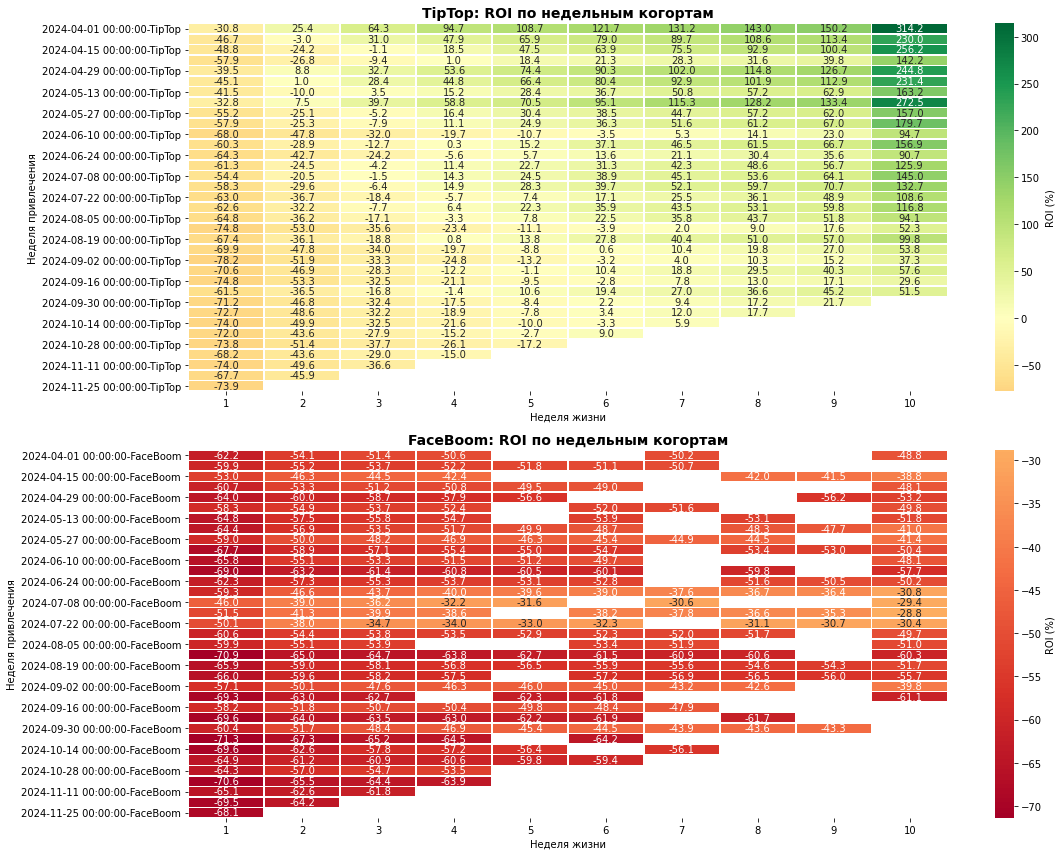

In [ ]:
# Создаем subplot для сравнения
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

# Тепловая карта для TipTop
sns.heatmap(roi_pivot_tiptop,
            annot=True,
            fmt='.1f',
            cmap='RdYlGn',
            center=0,
            linewidths=0.5,
            ax=ax1,
            cbar_kws={'label': 'ROI (%)'})
ax1.set_title('TipTop: ROI по недельным когортам', fontsize=14, fontweight='bold')
ax1.set_ylabel('Неделя привлечения')
ax1.set_xlabel('Неделя жизни')

# Тепловая карта для FaceBoom
sns.heatmap(roi_pivot_faceboom,
            annot=True,
            fmt='.1f',
            cmap='RdYlGn',
            center=0,
            linewidths=0.5,
            ax=ax2,
            cbar_kws={'label': 'ROI (%)'})
ax2.set_title('FaceBoom: ROI по недельным когортам', fontsize=14, fontweight='bold')
ax2.set_ylabel('Неделя привлечения')
ax2.set_xlabel('Неделя жизни')

plt.tight_layout()
plt.show()

К седьмой неделе маркетинговые вложения в канал TipTop начинают окупаться, и уже к 10 неделе выходят к окупаемомсти ROI в 200-300%. Что не скажешь насчет канала FaceBoom, маркетинговые вложение и к 10 неделе не окупились.

## Выводы и рекомендации

Сформулируйте общий вывод. Зафиксируйте основные результаты и инсайты. Например, охарактеризуйте аудиторию продукта, покажите распределение маркетинговых затрат по каналам привлечения, опишите каждый канал привлечения. Делайте акцент на сильных и слабых сторонах. Укажите, какие каналы привлечения не вышли на окупаемость и по каким причинам.

Дайте рекомендации отделу маркетинга: опишите, как повысить эффективность вложений в рекламу.


Основные результаты.

Заметен рост в 2 раза уникальных пользователей за весь период пользования приложением. (по DAU) Пользователи ежемесячно пользуются продуктом, рост есть и он стабилен. Возвращаемость в приложение почти линейная несмотря на рост уникальных пользователей. Все же не все остаются пользоваться приложением. С июня заметен скачок, дальше небольшой прирост показателя липкости. CAC в динамике с июня показывает существенный рост. Пожизненная ценность клиента LTV показывает рост, особенно заметен рост с июля и до конца октября. В ноябре показатель упал к уровню июня. Общая выручка за 28 дней выросла.
Видим резкий рост CAC с июня: увеличился с 0.74 до 1.18 (+59%), затраты на привлечение растут быстрее ценности. Отрицательный ROI: С июня ROI стал отрицательным, достигнув -34.6% в ноябре. Несмотря на рост LTV, рост CAC оказался непропорциональным.
Новый контент положительно повлиял на ценность пользователей, но маркетинговая стратегия требует корректировки для достижения окупаемости.

Рассмотрим в разрезе каналов. В большом количестве новые пользователи приходят из FaceBoom, с середины августа рост увеличился. Из канала TicTop пользователи приходят почти равномерно, с ростом с августа. Из MediaTornado и RocketSuperAds трафик почти одинаков, к концу года незаметный спад. Высокий рост пользователей приходит из канала TipTop с июня, по остальным каналам пользователи приходят равномерно.

Наблюдается рост месячной аудитории у канала TipTop и Faceboom. Несмотря на значительный рост по каналу TipTop пользователи не возвращаются в продукт так часто. Канал FaceBoom тоже показывает низкий % возвращаемости в приложение. TipTop показывает лучший процент удержания на 14 день. Средняя эффективность у RocketSuperAds и MediaTornado (8-9%). У FaceBoom самая низкая эффективность в удержание клиента. Канал TipTop и FaceBoom показывают высокую конверсию, FaceBoom с июля показывает спад. Канал RocketSuperAds показывает стабильную конверсию, MediaTornado с самой низкой конверсией.

В канал TipTop увеличили бюджет с июня в несколько раз ,видимо, посчитав, что это эффективный источник лидов. На втором месте канал FaceBoom по затратам. Снизили расходы у канала RocketSuperAds. Теперь видно, что рост CAC начался с июня за счет канала TipTop, в то время как CAC у каналов FaceBoom, MediaTornado не изменился, а у RocketSuperAds снизился с декабря.

Исходя из динамики ROI по источникам проведем анализ дла каналов - TipTop, FaceBoom. К седьмой неделе маркетинговые вложения в канал TipTop начинают окупаться, и уже к 10 неделе выходят к окупаемомсти ROI в 200-300%. Что не скажешь насчет канала FaceBoom, маркетинговые вложение и к 10 неделе не окупились.

Проблемы:
После запуска спортивного контента и изменения маркетинговой стратегии общая аудитория приложения (DAU) выросла, а выручка начала стагнировать.

Причина: Резкий рост стоимости привлечения пользователя (CAC), который с июня стал расти быстрее, чем пожизненная ценность (LTV). Это привело к отрицательному ROI, то есть маркетинговые затраты не окупаются за целевые 28 дней.

Новые пользователи, привлеченные по самым дорогим каналам, имеют низкую вовлеченность и возвращаемость, что не позволяет их LTV догнать высокий CAC.

Почему выручка стагнирует?

Маркетинг стал привлекать много некачественных пользователей, особенно из канала FaceBoom.
Эти пользователи:
- Имеют высокий CAC
- Не возвращаются в приложение
- Не генерируют достаточную LTV, чтобы оправдать затраты на их привлечение



Рекомендации по корректировке маркетинговой стратегии:

- Снизить расходы на канал FaceBoom.
Рассмотреть возможность полного отказа от этого канала, если оптимизация не даст быстрых результатов.

- Пересмотреть стратегию работы с каналом TipTop:
Это канал с высоким потенциалом и долгосрочной окупаемостью.

Скорректировать финансовое планирование. Поскольку LTV пользователей из TipTop превышает CAC только после 7-й недели:
повысить порог окупаемости и пересчитать маркетинговую стратегию и бюджетирование.

Проверить, можно ли улучшить удержание пользователей из TipTop в первые 4 недели
с помощью улучшенной онбординги, пуш-уведомлений или специальных предложений, чтобы ускорить окупаемость.

Увеличить инвестиции в эффективные каналы:
- RocketSuperAds показывает снижение CAC и стабильную эффективность.
- MediaTornado требует работы над повышением конверсии, но является стабильным источником.

Проблема не в продукте (новый контент привлек аудиторию), а в маркетинговой стратегии.
Привлечение пользователей сместилось на количество, а не на качество пользователей.